In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

Training Data

In [2]:
train_data = pd.read_csv("../data/train.csv")

In [3]:
print(train_data.shape)
train_data.head()

(594194, 21)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


Seperating the inputs and Targets

In [4]:
customer_features = train_data.drop(columns=["id", "Churn"])
churn_target = train_data["Churn"].map({
    "No": 0,
    "Yes": 1
})

Numerical and Categorical Columns

In [5]:
numeric_features = customer_features.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = customer_features.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


Split

In [6]:
X_train, X_valid, y_train, y_valid = train_test_split(
    customer_features,
    churn_target,
    test_size=0.20,
    random_state=31,
    stratify=churn_target
)

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numbers", StandardScaler(), numeric_features),
        (
            "categories",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

Regression Model

In [8]:
logistic_model = LogisticRegression(
    max_iter=300,
    solver="lbfgs"
)

Joining Prepocessing and Model

In [9]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("classifier", logistic_model)
    ]
)

Training the Model

In [10]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numbers', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categories',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier', LogisticRegression(max_iter=300))])

Predicted Class

In [11]:
valid_predictions = logistic_pipeline.predict(X_valid)

In [12]:
valid_probabilities = logistic_pipeline.predict_proba(X_valid)[:, 1]

In [13]:
print("First 10 class predictions:")
print(valid_predictions[:10])

print("\nFirst 10 churn probabilities:")
print(valid_probabilities[:10])

First 10 class predictions:
[0 0 1 0 0 0 0 0 0 0]

First 10 churn probabilities:
[0.09999522 0.24322369 0.7425947  0.16390954 0.12493992 0.07848299
 0.28275549 0.04145123 0.49403815 0.03374804]


Evaluation

In [14]:
logistic_results = {
    "Accuracy": accuracy_score(y_valid, valid_predictions),
    "Precision": precision_score(y_valid, valid_predictions),
    "Recall": recall_score(y_valid, valid_predictions),
    "F1-score": f1_score(y_valid, valid_predictions),
    "ROC-AUC": roc_auc_score(y_valid, valid_probabilities)
}

for metric, value in logistic_results.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.8546
Precision: 0.6845
Recall: 0.6576
F1-score: 0.6708
ROC-AUC: 0.9082


Classification Report

In [15]:
print(
    classification_report(
        y_valid,
        valid_predictions,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.90      0.91      0.91     92076
       Churn       0.68      0.66      0.67     26763

    accuracy                           0.85    118839
   macro avg       0.79      0.78      0.79    118839
weighted avg       0.85      0.85      0.85    118839



Confusion Matrix

In [16]:
logistic_confusion_matrix = confusion_matrix(
    y_valid,
    valid_predictions
)

print(logistic_confusion_matrix)

[[83963  8113]
 [ 9164 17599]]


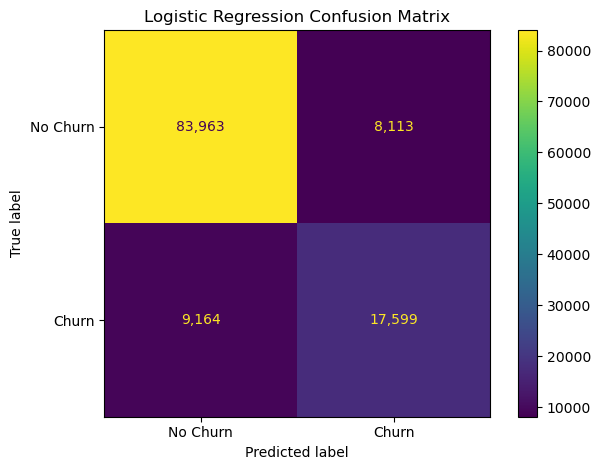

In [17]:
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    valid_predictions,
    display_labels=["No Churn", "Churn"],
    values_format=","
)

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.savefig(
    "../screenshots/logistic_confusion_matrix.png",
    dpi=150
)
plt.show()

ROC Curve

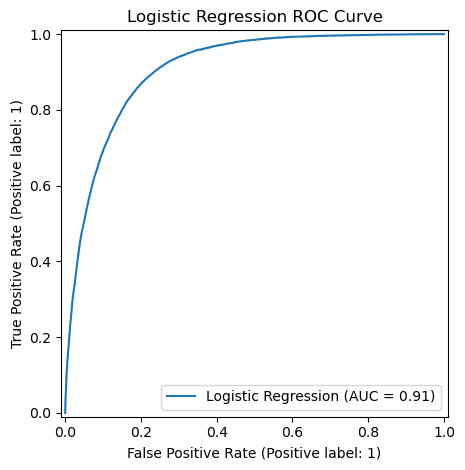

In [18]:
RocCurveDisplay.from_predictions(
    y_valid,
    valid_probabilities,
    name="Logistic Regression"
)

plt.title("Logistic Regression ROC Curve")
plt.tight_layout()
plt.savefig(
    "../screenshots/logistic_roc_curve.png",
    dpi=150
)
plt.show()

Class-Weighted Logistic Regression

In [19]:
weighted_preprocessor = ColumnTransformer(
    transformers=[
        ("numbers", StandardScaler(), numeric_features),
        (
            "categories",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

Creating the Weighted Model

In [20]:
weighted_logistic_model = LogisticRegression(
    max_iter=300,
    solver="lbfgs",
    class_weight="balanced"
)


Pipeline

In [21]:
weighted_logistic_pipeline = Pipeline(
    steps=[
        ("preprocessing", weighted_preprocessor),
        ("classifier", weighted_logistic_model)
    ]
)

Training

In [22]:
weighted_logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numbers', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categories',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=300))])

In [23]:
weighted_predictions = weighted_logistic_pipeline.predict(X_valid)

weighted_probabilities = weighted_logistic_pipeline.predict_proba(
    X_valid
)[:, 1]

In [24]:
weighted_results = {
    "Accuracy": accuracy_score(y_valid, weighted_predictions),
    "Precision": precision_score(y_valid, weighted_predictions),
    "Recall": recall_score(y_valid, weighted_predictions),
    "F1-score": f1_score(y_valid, weighted_predictions),
    "ROC-AUC": roc_auc_score(y_valid, weighted_probabilities)
}

for metric, value in weighted_results.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.8075
Precision: 0.5447
Recall: 0.8835
F1-score: 0.6739
ROC-AUC: 0.9081


In [25]:
print(
    classification_report(
        y_valid,
        weighted_predictions,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.96      0.79      0.86     92076
       Churn       0.54      0.88      0.67     26763

    accuracy                           0.81    118839
   macro avg       0.75      0.83      0.77    118839
weighted avg       0.87      0.81      0.82    118839



In [26]:
weighted_confusion_matrix = confusion_matrix(
    y_valid,
    weighted_predictions
)

print(weighted_confusion_matrix)

[[72314 19762]
 [ 3118 23645]]


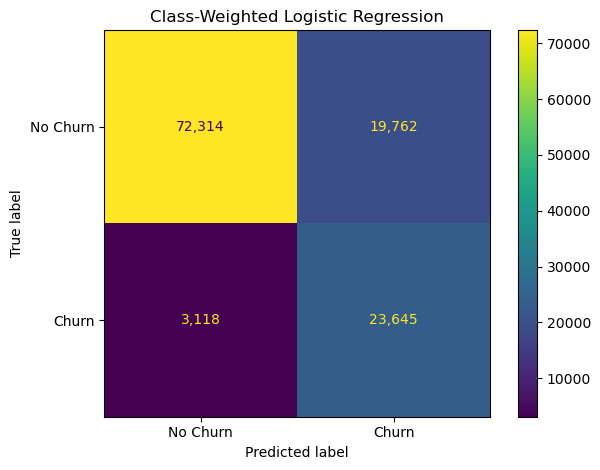

In [27]:
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    weighted_predictions,
    display_labels=["No Churn", "Churn"],
    values_format=","
)

plt.title("Class-Weighted Logistic Regression")
plt.tight_layout()
plt.savefig(
    "../screenshots/weighted_logistic_confusion_matrix.png",
    dpi=150
)
plt.show()

In [28]:
logistic_comparison = pd.DataFrame(
    [
        logistic_results,
        weighted_results
    ],
    index=[
        "Logistic Regression",
        "Weighted Logistic Regression"
    ]
)

logistic_comparison.round(4)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.8546,0.6845,0.6576,0.6708,0.9082
Weighted Logistic Regression,0.8075,0.5447,0.8835,0.6739,0.9081
